In [3]:
#Step 2
import pandas as pd
import os

dataset_path = r"C:\Users\User\Downloads\ENAJE\ENAJE_Activity_7\spotify_top_1000_tracks.csv"

df = pd.read_csv(dataset_path, encoding="utf-8")

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

print("Dataset loaded and basic preprocessing complete!")
print(df.head(3))

Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [4]:
#Step 3
import numpy as np

df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()

df['year'] = df['year'].fillna(0).astype(int)

cols_to_drop = ['spotify_url', 'id', 'release_date']

if 'time_signature' in df.columns:
    cols_to_drop.append('time_signature')
if 'key' in df.columns:
    cols_to_drop.append('key')
if 'mode' in df.columns:
    cols_to_drop.append('mode')

df = df.drop(columns=cols_to_drop, errors='ignore')

tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut( 
        df['tempo'], bins=tempo_bins,
        labels=tempo_labels, right=False
    )
    print("Feature 'tempo_category' created.")
else:
    print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.")

df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print(f" Data cleaning and feature engineering complete.")
print(f"Final Row Count after deduplication: {len(df)}")

 Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


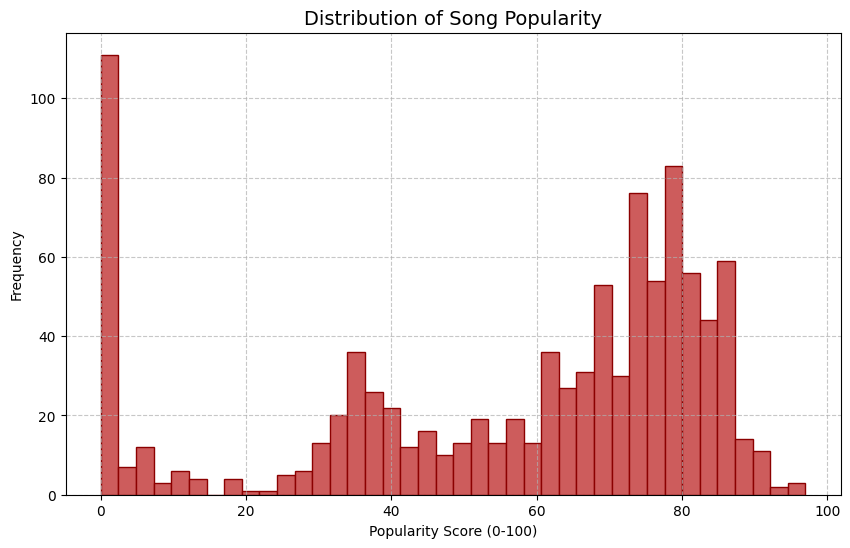

In [6]:
#1. Histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=40, color='indianred',edgecolor='darkred')
plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_16392\1356960545.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


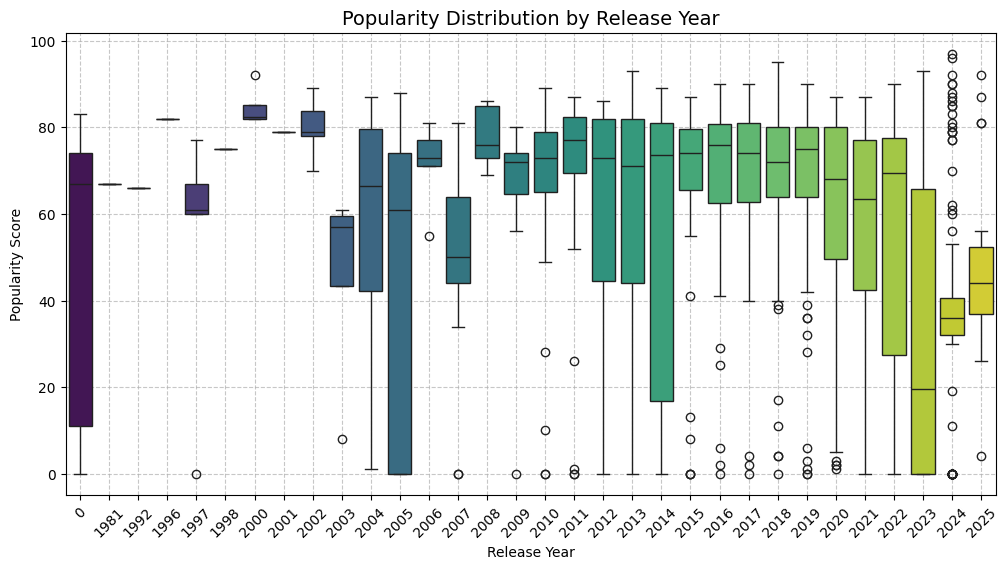

In [5]:
#2. Boxplot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

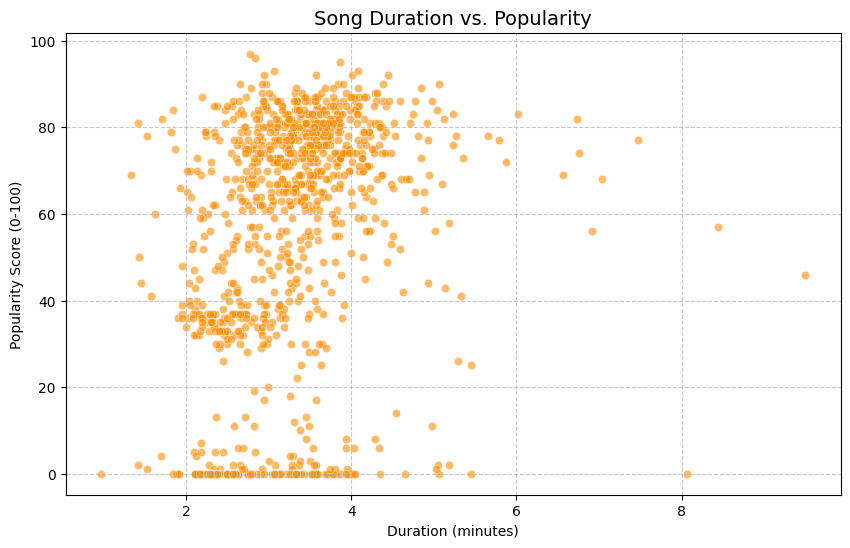

In [6]:
#3. Scatter Plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6,
color='darkorange')
plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

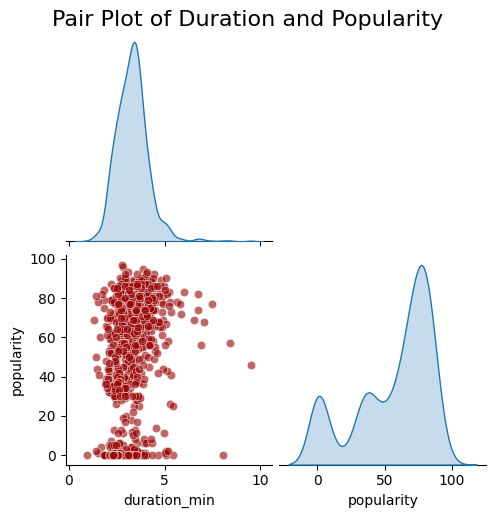

In [7]:
#4. Pair Plot

import matplotlib.pyplot as plt
import seaborn as sns

key_features = ['duration_min', 'popularity']

sns.pairplot(
    df[key_features],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 'color': '#990000'}
)
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)
plt.show()

<Figure size 800x800 with 0 Axes>

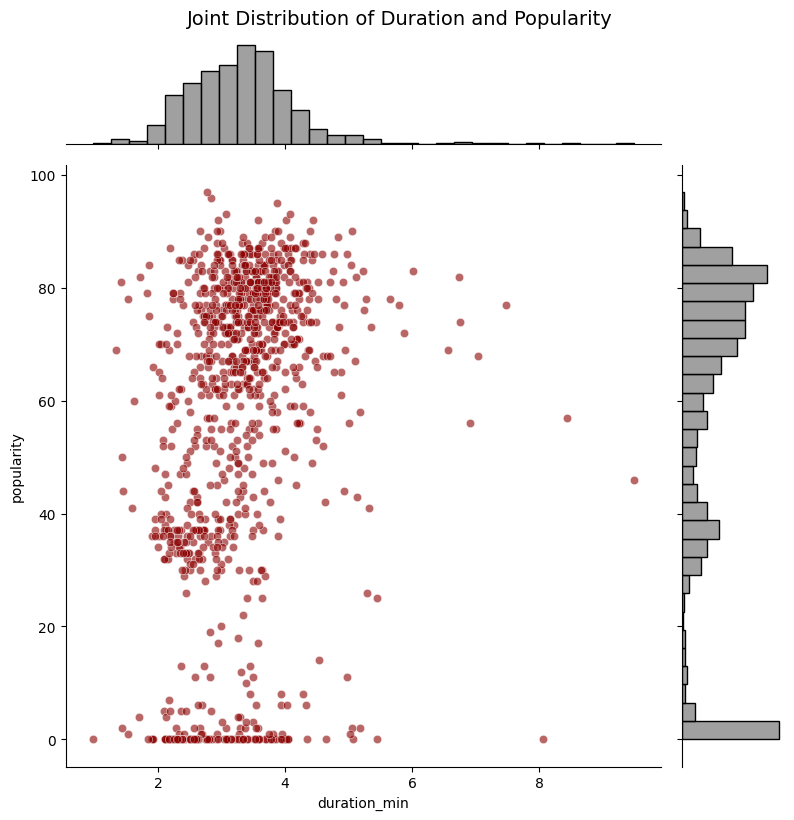

In [8]:
#5. Joint Plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 8))
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter',
    height=8, 
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'},
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)
plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02,
fontsize=14)
plt.show()

In [35]:
#6. Animated Line Chart 

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

csv_files = r"C:\Users\User\Downloads\ENAJE\ENAJE_Activity_7\spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_files)

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.dropna(subset=['year'])

yearly_popularity = df.groupby('year')['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line, = ax.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')
ax.set_title("Evolution of Track Popularity Over Time", fontsize=14, color='navy')
ax.set_xlabel("Year of Release", fontsize=12)
ax.set_ylabel("Average Popularity", fontsize=12)
ax.legend(loc="upper left")
plt.tight_layout()

def animate(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=100, repeat=False)

gif_path = os.path.abspath("yearly_popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f" GIF saved successfully at: {gif_path}")

webbrowser.open(f"file://{gif_path}") 
plt.close(fig)

 GIF saved successfully at: c:\Users\User\Downloads\ENAJE\ENAJE_Activity_7\yearly_popularity_trend.gif


IV. DATA AND OBSERVATION 

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
student_name = "James Edward Enaje"
student_id = "20253736"
id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5)
% 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4)
% 256:02x}"

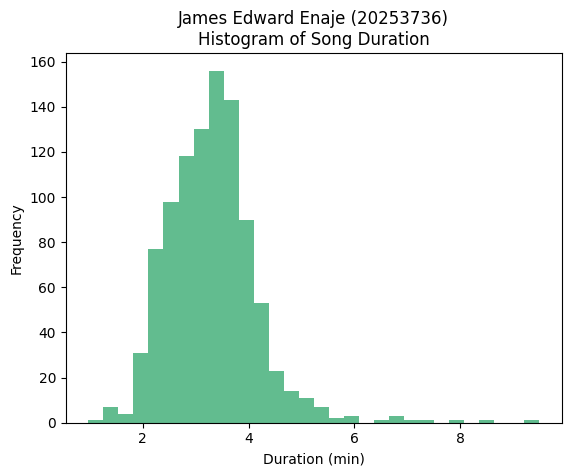

In [11]:
#1
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_16392\2452057604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


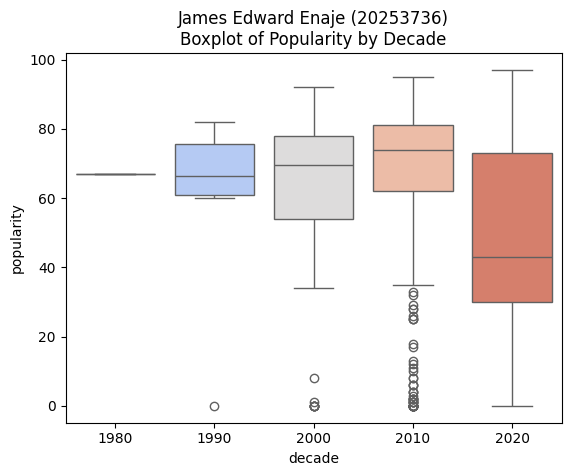

In [12]:
#2
df['decade'] = (df['release_date'].dt.year // 10) * 10
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_16392\310259632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


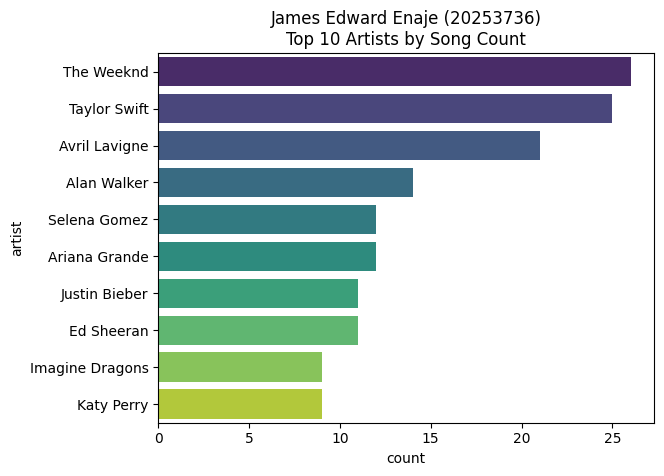

In [13]:
#3
sns.countplot(y='artist', data=df,
order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_16392\3704709707.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',scale='width')
C:\Users\User\AppData\Local\Temp\ipykernel_16392\3704709707.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',scale='width')


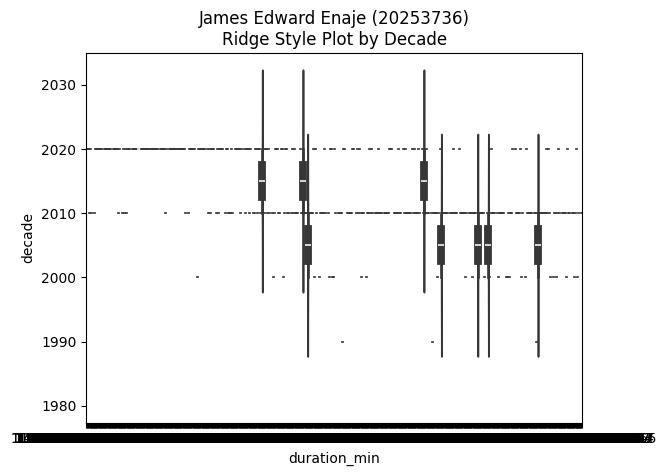

In [14]:
#4
sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',scale='width')
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.show()


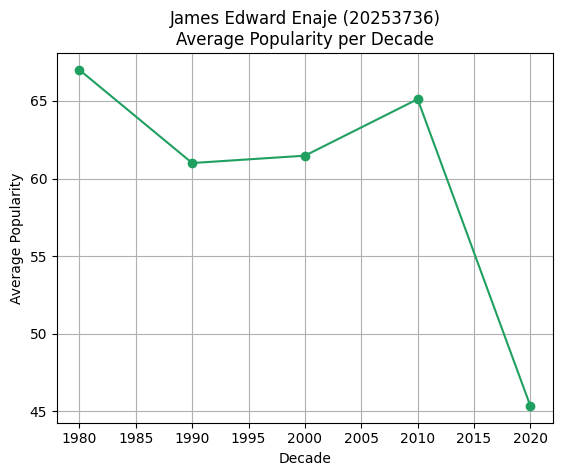

In [15]:
#5
avg_pop = df.groupby('decade')['popularity'].mean()
avg_pop.plot(kind='line', color=color1, marker='o')
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()

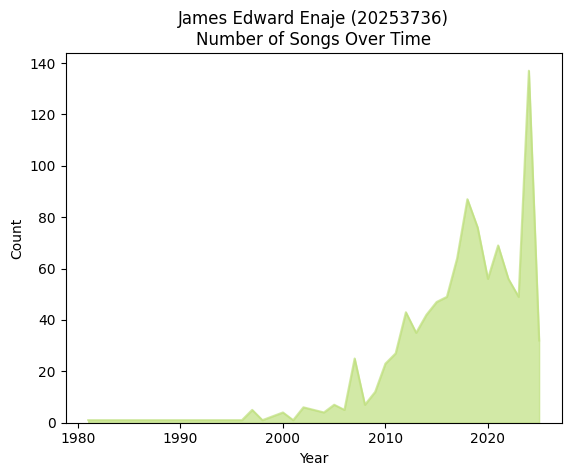

In [16]:
#6
df['release_year'] = pd.to_datetime(df['release_date'],
errors='coerce').dt.year
count_by_year = df['release_year'].value_counts().sort_index()
count_by_year.plot(kind='area', color=color2, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

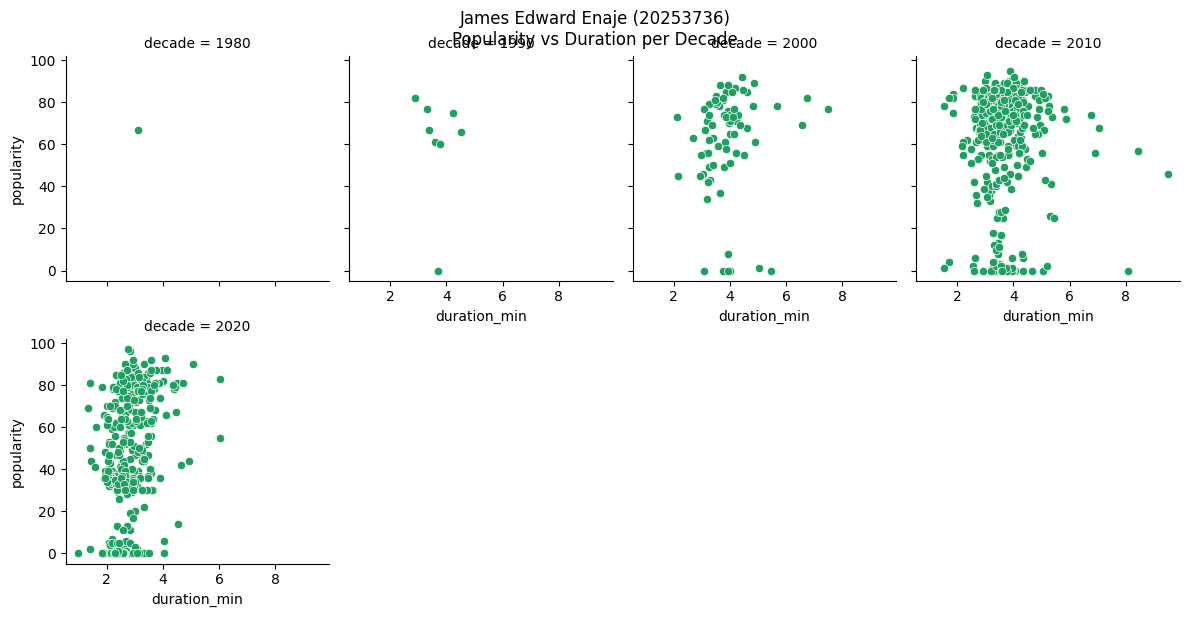

In [17]:
#7
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity',
color=color1)
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02)
plt.show()

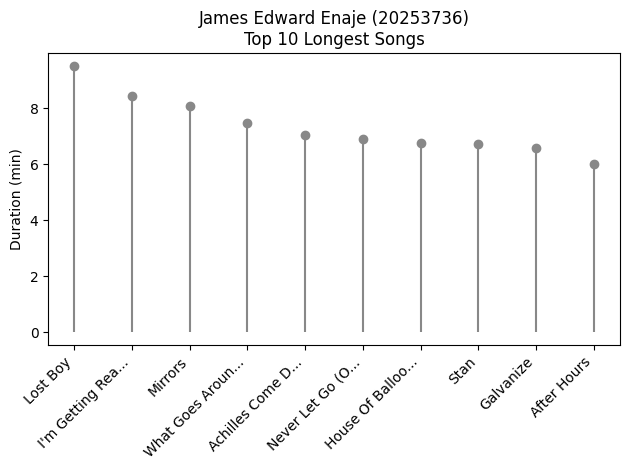

In [18]:
#8
longest = df.nlargest(10, 'duration_min')

truncated_titles = [title[:15] + "..." if len(title) > 15 else title for title in longest['track_name']]

plt.stem(truncated_titles, longest['duration_min'], 
         linefmt='#888888', markerfmt='o', basefmt=" ")


plt.xticks(rotation=45, ha='right')
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()


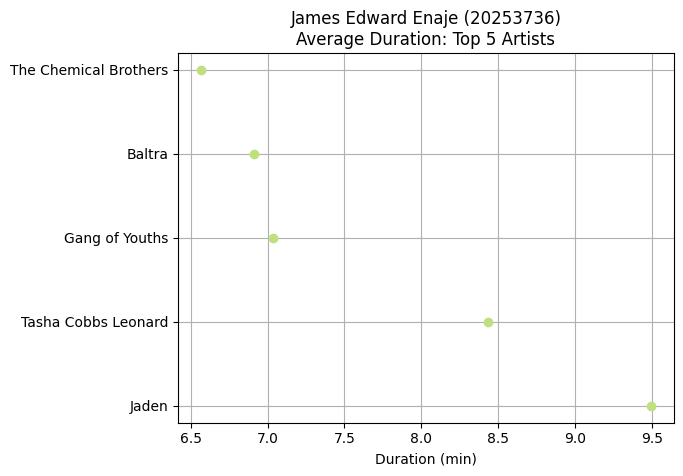

In [19]:
#9
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.grid(True)
plt.show()

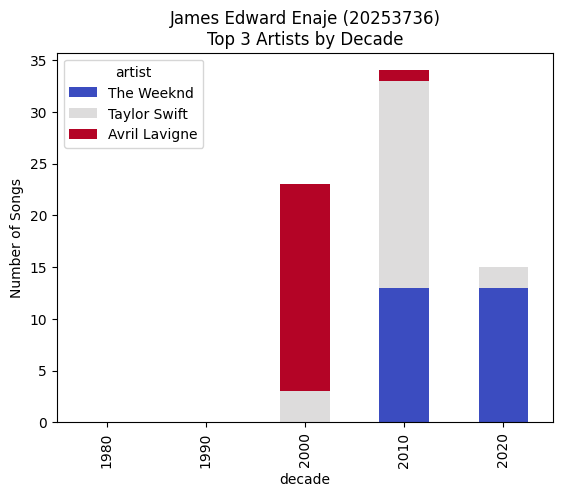

In [20]:
#10
crosstab = pd.crosstab(df['decade'], df['artist'])
top3 = df['artist'].value_counts().head(3).index
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.show()

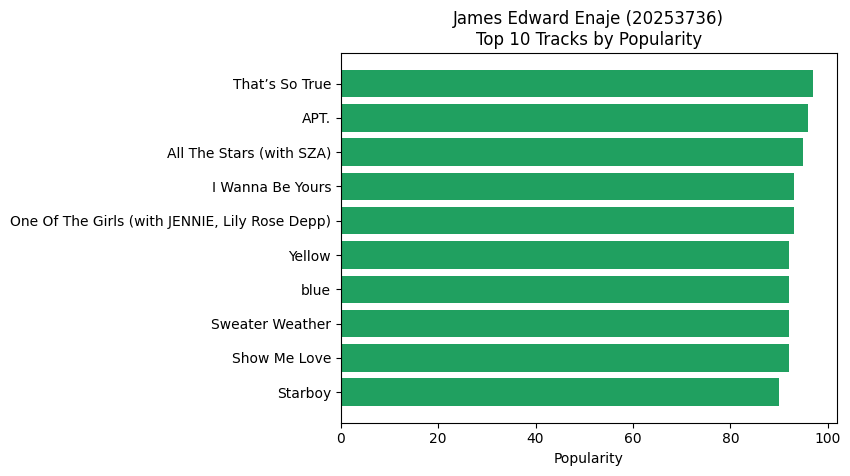

In [21]:
#11
top_tracks = df.nlargest(10, 'popularity')
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_16392\2476633795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
C:\Users\User\AppData\Local\Temp\ipykernel_16392\2476633795.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


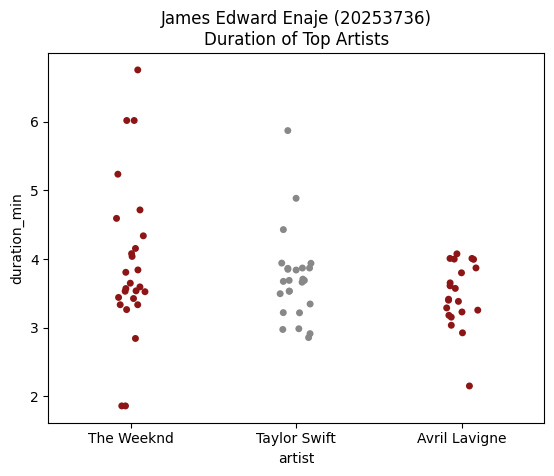

In [22]:
#12
top_artists = df['artist'].value_counts().head(3).index
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
y='duration_min', palette=['#8C1515', '#888888'])
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.show()

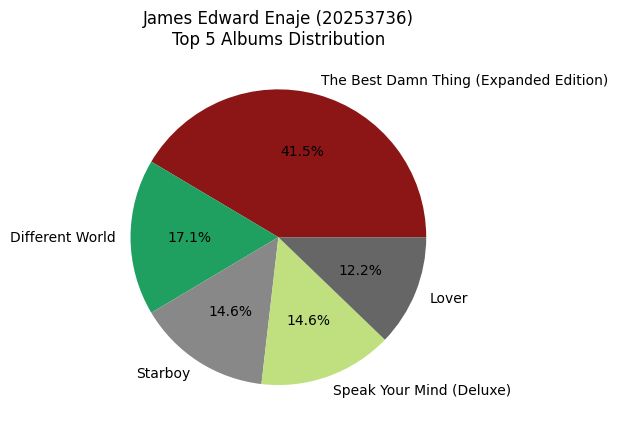

In [23]:
#13
top_albums = df['album'].value_counts().head(5)
colors = ['#8C1515', color1, '#888888', color2, '#666666']
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%',
colors=colors)
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()

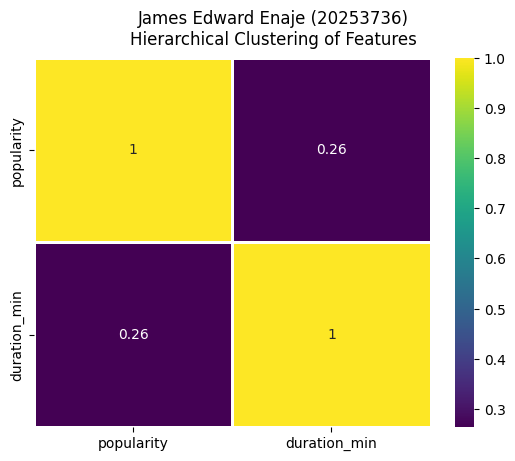

In [38]:
#14
numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()
sns.heatmap(df_numeric.corr(), annot=True, cmap='viridis', linewidths=.75)
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features")
plt.show()

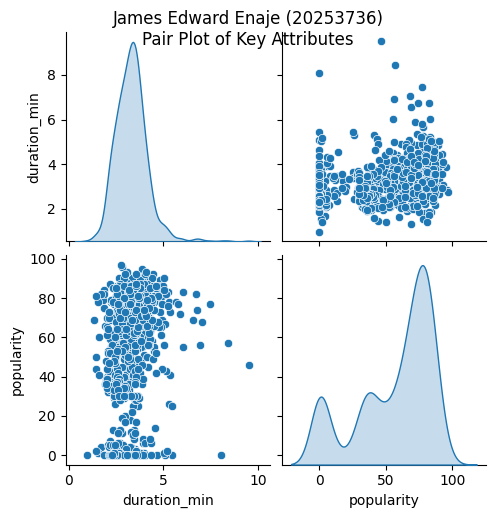

In [25]:
#15
sns.pairplot(df[['duration_min', 'popularity', 'release_date']],
diag_kind='kde')
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02)
plt.show()

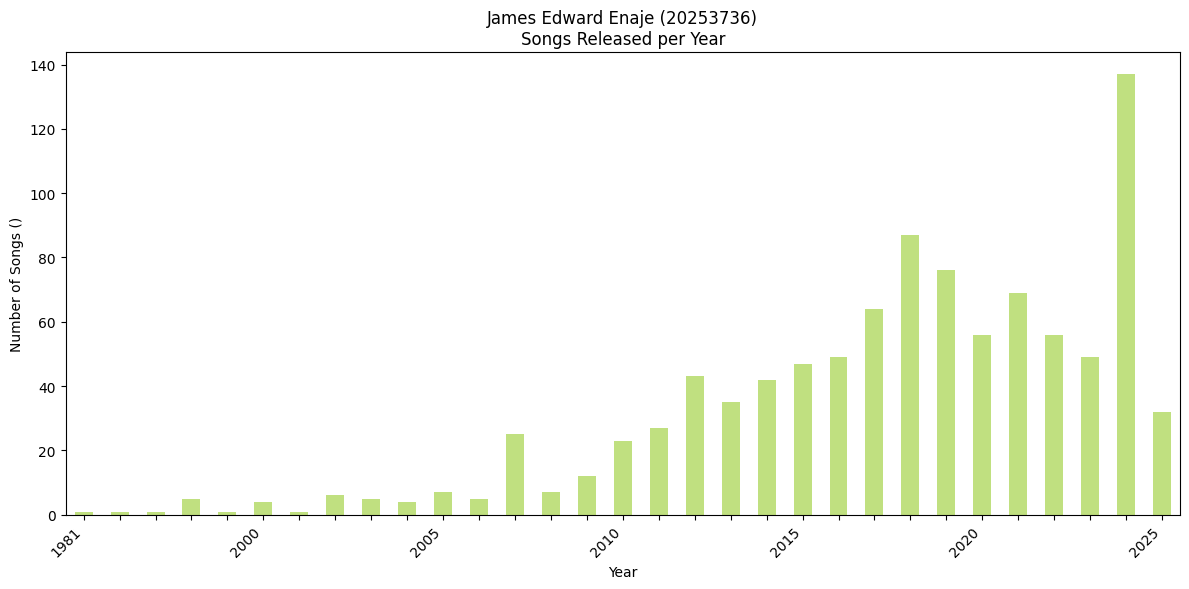

In [26]:
#16
import matplotlib.ticker as ticker

yearly_counts = df['release_date'].dt.year.value_counts().sort_index()

ax = yearly_counts.plot(kind='bar', color=color2, figsize=(12, 6))

plt.xticks(rotation=45, ha='right')

for i, t in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        t.set_visible(False)

def format_thousands(x, pos):
    if x >= 1e6:
        return f'{x*1e-6:g}M'
    elif x >= 1e3:
        return f'{x*1e-3:g}K'
    return f'{x:g}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_thousands))

plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.xlabel('Year')
plt.ylabel('Number of Songs ()')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_16392\3167849372.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity',


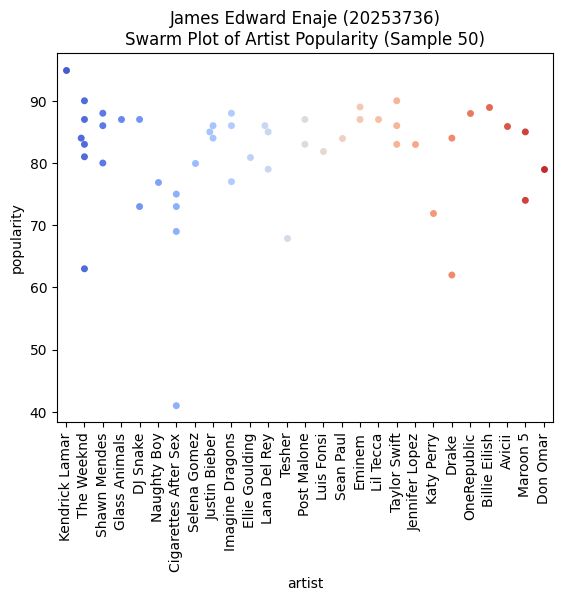

In [27]:
#17
sns.swarmplot(data=df.head(50), x='artist', y='popularity',
palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=90)
plt.show()

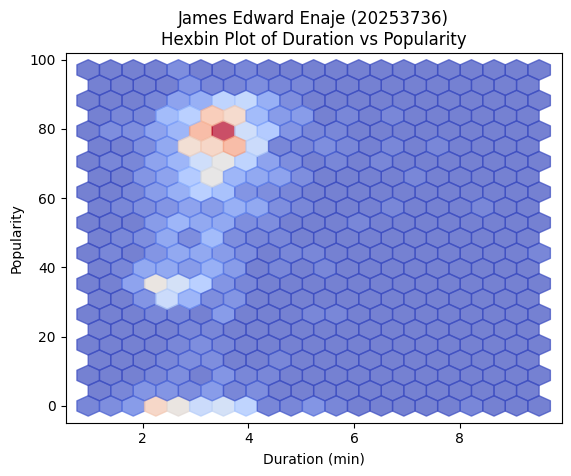

In [28]:
#18
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20,cmap='coolwarm', alpha=0.7)
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")
plt.show()

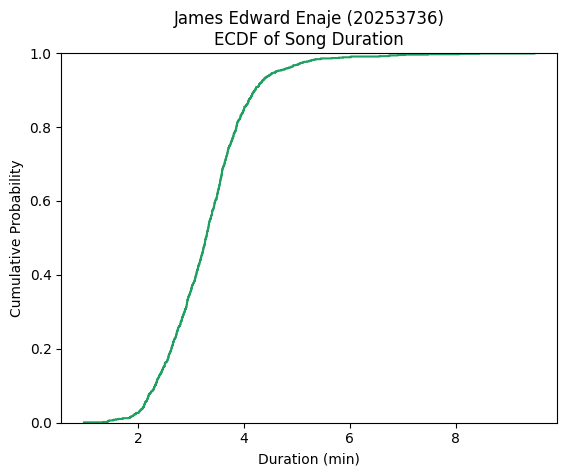

In [29]:
#19
sns.ecdfplot(data=df, x='duration_min', color=color1)
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')
plt.show()

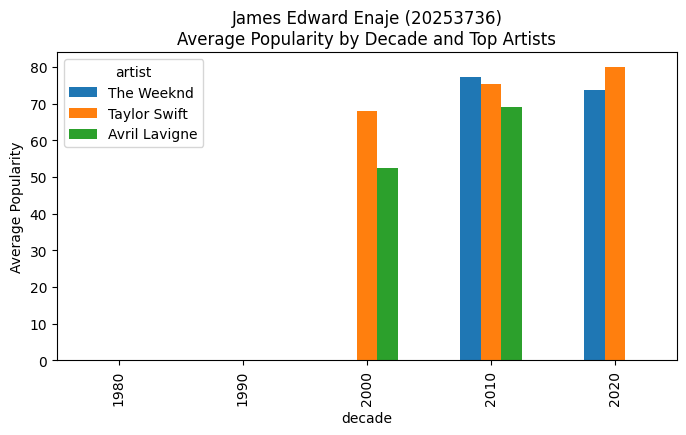

In [30]:
#20
avg_artist_decade = df.groupby(['decade','artist'])['popularity'].mean().unstack().fillna(0) 
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4))
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.ylabel('Average Popularity')
plt.show()


E. ADDITIONAL EXERCISES

                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  
622      7.035767  
689      6

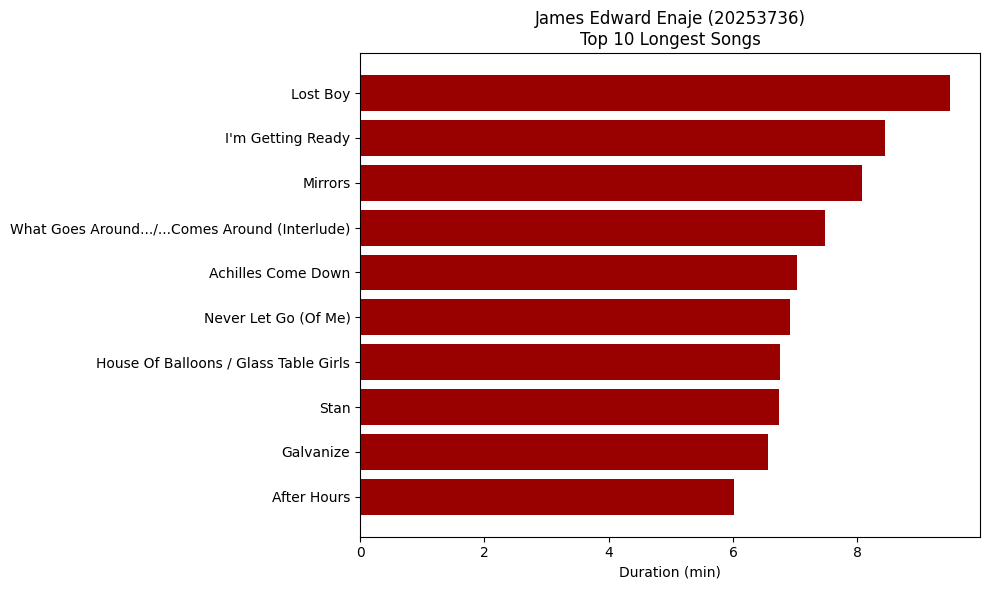

In [31]:
# 1. Identify Longest Tracks
color_bar = '#990000' 

top_10_longest = df.nlargest(10, 'duration_min')
print(top_10_longest[['track_name', 'artist', 'duration_min']])

plt.figure(figsize=(10, 6))
plt.barh(top_10_longest['track_name'], top_10_longest['duration_min'], color=color_bar)

plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.xlabel('Duration (min)')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

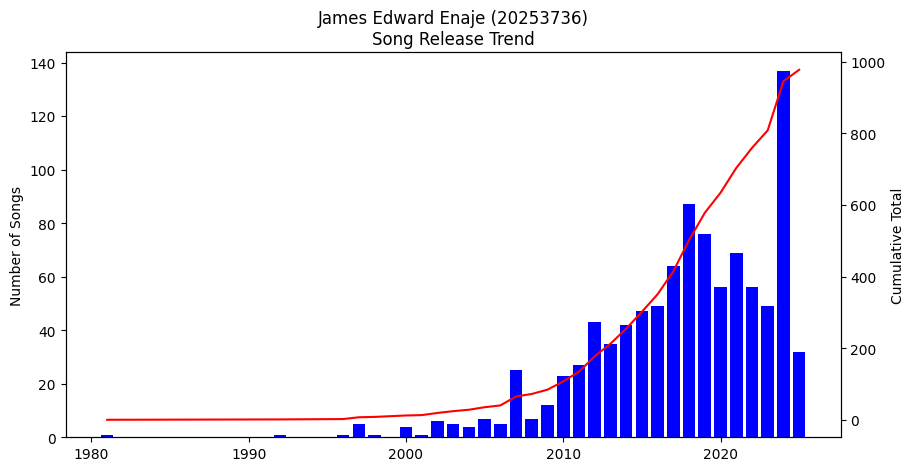

In [33]:
#2. Song Release Trend

student_name = "James Edward Enaje"
student_id = "20253736"
color_bar = 'blue'
color_line = 'red'

yearly_counts = df['year'].value_counts().sort_index()

cumulative_total = yearly_counts.cumsum()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(yearly_counts.index, yearly_counts.values, color=color_bar, label='New Releases')
ax1.set_ylabel('Number of Songs')

ax2 = ax1.twinx()
ax2.plot(cumulative_total.index, cumulative_total.values, color=color_line, label='Total Growth')
ax2.set_ylabel('Cumulative Total')

plt.title(f"{student_name} ({student_id})\nSong Release Trend")
plt.xlabel('Year')
plt.show()

In [34]:
#3. 3. Animated Density Map of Duration vs Popularity

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

student_name = "James Edward Enaje"
student_id = "20253736"
cmap_color = 'YlOrRd' 

fig, ax = plt.subplots(figsize=(10, 6))

years = sorted(df['year'].unique())

def update(frame):
    ax.clear() 
    
    
    current_year = years[frame]
    data_subset = df[df['year'] == current_year]
    
    
    hb = ax.hexbin(data_subset['duration_min'], data_subset['popularity'], 
                   gridsize=20, cmap=cmap_color, mincnt=1)
    
    ax.set_title(f"{student_name} ({student_id})\nConcentration in {current_year}")
    ax.set_xlabel('Duration (min)')
    ax.set_ylabel('Popularity')
    ax.set_xlim(df['duration_min'].min(), df['duration_min'].max())
    ax.set_ylim(0, 100)
    
    return hb,

ani = FuncAnimation(fig, update, frames=len(years), interval=500, blit=True)

plt.close() 
HTML(ani.to_jshtml())